In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1812,ham,\Getting tickets 4 walsall tue 6 th march. My ...,NaN,NaN,NaN
1132,ham,Good morning princess! How are you?,NaN,NaN,NaN
3563,ham,Do you always celebrate NY's with your family ?,NaN,NaN,NaN
5542,ham,Armand says get your ass over to epsilon,NaN,NaN,NaN
1849,ham,You got job in wipro:)you will get every thing...,NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
#1. data cleaning 
#2. EDA
#3. data preprocessing 
#4. model building 
#5. evaluation 
#6. improvement
#7. website
#8. deployment 

## 1.DATA CLEANING 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
#dropping last 3 cols

df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(5)

,v1,v2
5163,ham,Ok leave no need to ask
3859,ham,Yep. I do like the pink furniture tho.
2489,ham,I have 2 docs appointments next week.:/ I'm ti...
1069,ham,Jus finish bathing...
999,ham,"Aight will do, thanks again for comin out"


In [7]:
#renaming the columns

df.rename(columns={'v1':'target', 'v2':'text'},inplace=True)
df.sample(5)

,target,text
2538,ham,The monthly amount is not that terrible and yo...
5085,ham,Sorry i missed your call. Can you please call ...
3499,spam,Dorothy@kiefer.com (Bank of Granite issues Str...
1983,ham,I wnt to buy a BMW car urgently..its vry urgen...
601,ham,If u sending her home first it's ok lor. I'm n...


In [8]:
#checking for null values 

df.isna().sum()

target    0
text      0
dtype: int64

In [9]:
#label encoding 

from sklearn.preprocessing import LabelEncoder 
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
#checking duplicate values  

df.duplicated().sum()

np.int64(403)

In [11]:
#remove duplicates

df = df.drop_duplicates(keep='first')

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(5169, 2)

## 2.EDA

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

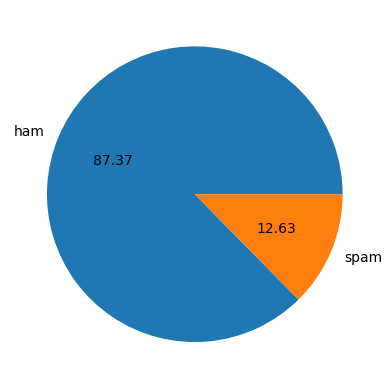

In [16]:
import matplotlib.pyplot as plt 
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

In [17]:
#data is imbalanced 

In [17]:
import nltk

In [18]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aditya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aditya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
# number of characters 

df['num_characters'] = df['text'].apply(len)

In [21]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [22]:
# number of words 

df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [23]:
# number of sentences 

df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
# ham 

df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
# spam 

df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [27]:
# visualizing the difference in number of characters and words in spam and ham messages 

import seaborn as sns 

<Axes: xlabel='num_characters', ylabel='Count'>

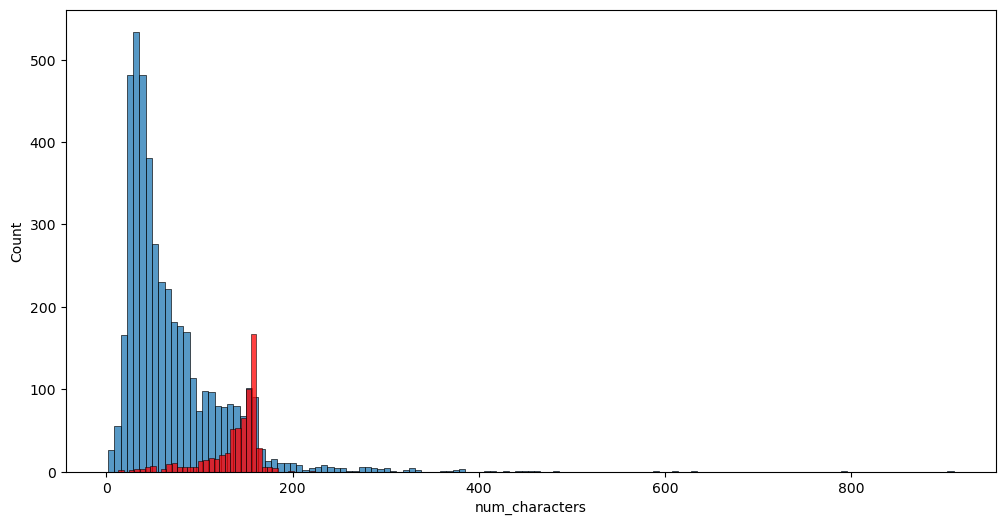

In [25]:
# diff in num of characters 

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

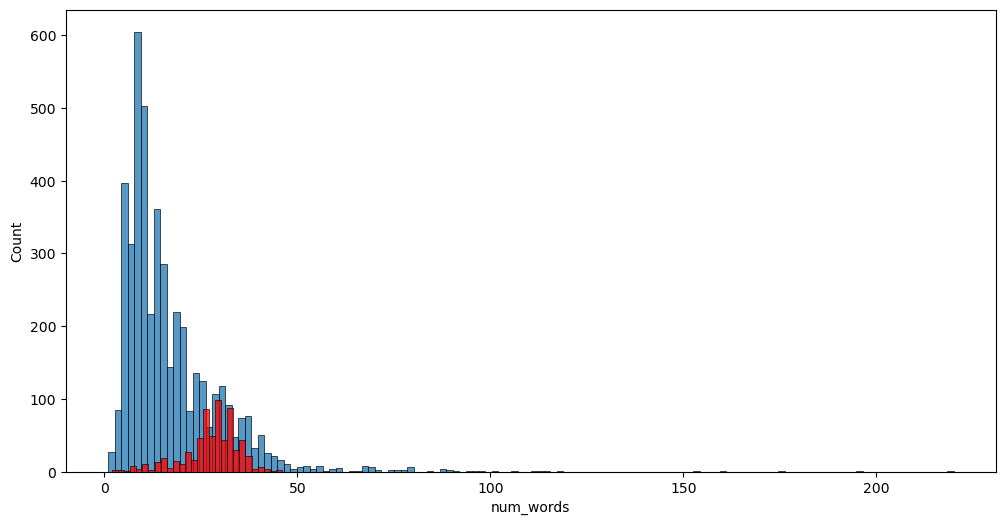

In [26]:
# diff in num of words 

plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color='red')

In [27]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


<Axes: >

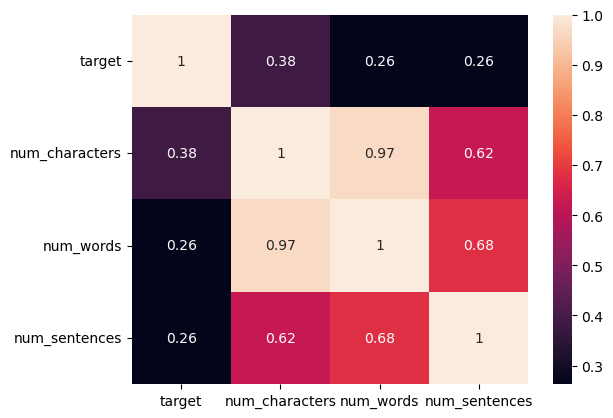

In [28]:
# correlations amomg the features 

sns.heatmap(df[['target','num_characters','num_words','num_sentences']].corr(),annot=True)

## 3. DATA PREPROCESSING 
    -lower case 
    -tokenization
    -removing speacial characters
    -removing punctuation and stop words 
    -stemming

In [19]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y =[]
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [20]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [21]:
transform_text('hi how are you?, you are 20 %% years old congrats!,happy birthday to you!, sending you lots of love.')

'hi 20 year old congrat happi birthday send lot love'

In [22]:
df['transformed_text'] = df['text'].apply(transform_text)

In [23]:
df.sample(10)

,target,text,transformed_text
895,0,Superb Thought- \Be grateful that u dont have ...,superb grate u dont everyth u want mean u stil...
3969,0,That's the trouble with classes that go well -...,troubl class go well due dodgey one expect min...
255,0,Don't necessarily expect it to be done before ...,necessarili expect done get back though headin
3830,0,Let's pool our money together and buy a bunch ...,let pool money togeth buy bunch lotto ticket w...
3079,0,S.s:)i thinl role is like sachin.just standing...,thinl role like stand other hit
292,0,Oops. 4 got that bit.,oop 4 got bit
2974,0,"Don't worry, * is easy once have ingredients!",worri easi ingredi
1964,0,Honeybee Said: *I'm d Sweetest in d World* God...,honeybe said sweetest world god laugh amp said...
4537,0,Dare i ask... Any luck with sorting out the car?,dare ask luck sort car
57,0,"Sorry, I'll call later in meeting.",sorri call later meet


In [193]:
!pip install wordcloud

In [45]:
# generating wordcloud of most frequently used words in ham and spam sms

from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

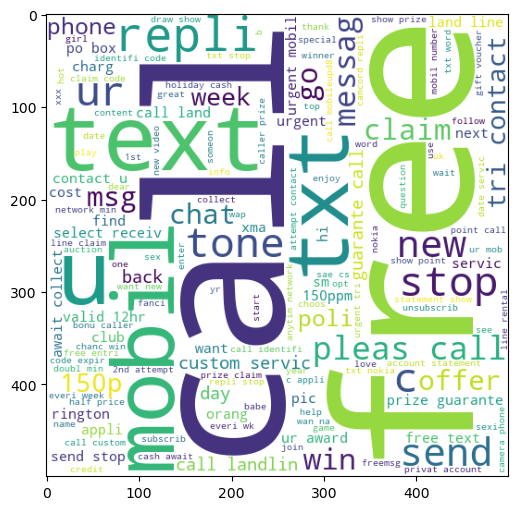

In [46]:
# spam wordcloud

spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

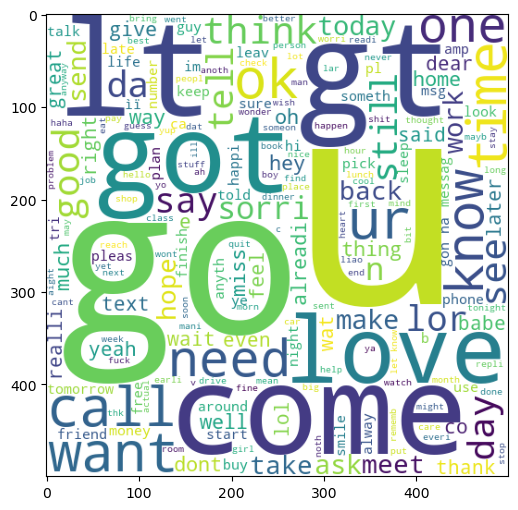

In [47]:
# ham wordcloud

ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

## 4. MODEL BUILDING 

In [24]:
# converting text into numeric data ( used cv and tdidf both and chose tfidf finally)

from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [25]:
# creating our x and y faetures to work with the ml models 

In [26]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [27]:
X.shape

(5169, 3000)

In [28]:
y = df['target'].values

In [29]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [30]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [31]:
# using naive bayes algorithm 
# importing metrics(sklearn) to compare model perrformances

from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [32]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [33]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8694390715667312
[[788 108]
 [ 27 111]]
0.5068493150684932


In [34]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9709864603481625
[[896   0]
 [ 30 108]]
1.0


In [111]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


In [112]:
# chose ifidf with multinomialNB


In [43]:
# now comaprig mmultinomial with some other models ( just for observation)


In [114]:
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [115]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [116]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt
}

In [43]:
def train_classifier(clf,X_train,X_test,y_train,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [118]:
accuracy_scores = []
precision_scores = [] 

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf,X_train,X_test,y_train,y_test)

    print("name ",name)
    print("accuarcy-",current_accuracy)
    print("precision-",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

name  SVC
accuarcy- 0.9758220502901354
precision- 0.9747899159663865
name  KN
accuarcy- 0.9052224371373307
precision- 1.0
name  NB
accuarcy- 0.9709864603481625
precision- 1.0
name  DT
accuarcy- 0.9303675048355899
precision- 0.8173076923076923
name  LR
accuarcy- 0.9584139264990329
precision- 0.9702970297029703
name  RF
accuarcy- 0.9758220502901354
precision- 0.9829059829059829
name  AdaBoost
accuarcy- 0.9245647969052224
precision- 0.8488372093023255
name  BgC
accuarcy- 0.9584139264990329
precision- 0.8682170542635659
name  ETC
accuarcy- 0.9748549323017408
precision- 0.9745762711864406
name  GBDT
accuarcy- 0.9468085106382979
precision- 0.9191919191919192


In [119]:
performance_df = pd.DataFrame({'algorithm':clfs.keys(), 'accuracy':accuracy_scores, 'precision':precision_scores}).sort_values('precision',ascending=False)
performance_df

,algorithm,accuracy,precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.975822,0.982906
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.958414,0.970297
9,GBDT,0.946809,0.919192
7,BgC,0.958414,0.868217
6,AdaBoost,0.924565,0.848837
3,DT,0.930368,0.817308


In [99]:
# nb and rf are giving the best results 

In [120]:
# tried minmax scaling but didnt improve the model performance for nb , so didn't integrate it

In [121]:
# tried votingclassifier and stackign classifier but still didn't see better perfformance , so didn't integrate that either

In [123]:
# precision is very important for this model , taking that in account :

In [124]:
# MNB(with tfidf(max_ft=3000))

In [44]:
import pickle 
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))